https://github.com/exchhattu/TimeSeriesWeatherForecast-Regression-SVR/blob/master/notebook/Weather.ipynb

In [1]:

from SSA2 import SSAv3

import pandas as pd # for using pandas daraframe
import numpy as np # for som math operations
from sklearn.preprocessing import StandardScaler # for standardizing the Data
from sklearn.decomposition import PCA # for PCA calculation
import matplotlib.pyplot as plt # for plotting


# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.colors as colors

import seaborn as sns

mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

font      = {'family':'arial', 'style':'normal', 'size':18}
axis_font = {'family':'arial', 'style':'normal', 'size':18}
plt.rc('font', **font)

plt.style.use('fivethirtyeight')

%matplotlib inline

In [2]:
df = pd.read_csv('105vPCA.csv', parse_dates=True, index_col='DateTime',encoding="windows-1252") # или 106.csv
df = df.fillna(0)
df.head(5)

,AffinityIndex,SerialNumber,H,Tmean,WmeanH,WindDirectionH(Â°),WminH,WmaxH,WmeanV,AtmosphericPressure,RelativeHumidity,TdewPoint(Â°C),WaterVaporElasticity,AbsolutusHumidity,DensityofAir,SpeedofSoundinAir
DateTime,,,,,,,,,,,,,,,,
2017-07-22 00:01:00,6,12427AMK-03,15,15.86,0.20,94.53,0.01,0.44,-0.13,750.45,100.0,15.86,17.99,14.53,1.1954,342.12
2017-07-22 00:02:00,6,12427AMK-03,15,15.88,0.28,104.28,0.15,0.53,-0.19,750.45,100.0,15.88,18.01,14.55,1.1953,342.14
2017-07-22 00:03:00,6,12427AMK-03,15,15.87,0.23,68.53,0.11,0.36,-0.19,750.45,100.0,15.87,17.99,14.54,1.1954,342.13
2017-07-22 00:04:00,6,12427AMK-03,15,15.95,0.17,47.04,0.01,0.33,-0.18,750.45,100.0,15.95,18.09,14.62,1.1950,342.18
2017-07-22 00:05:00,6,12427AMK-03,15,16.01,0.06,11.99,0.01,0.22,-0.19,750.45,100.0,16.01,18.16,14.68,1.1947,342.22


In [3]:
del df['SerialNumber'] 
del df['AffinityIndex'] 
del df['H'] 

In [4]:
df.shape


(1186390, 13)

In [5]:
desc = df.describe().T
desc['count'] = desc['count'].astype(int)
print(desc)

                        count        mean         std        min       25%  \
Tmean                 1186390    2.059975   14.006564  -41.18000   -6.9200   
WmeanH                1186390    1.997282    1.315817    0.02000    1.0900   
WindDirectionH(Â°)    1186390  177.549004   91.700972    0.00000  122.0700   
WminH                 1186390    0.626939    2.279066    0.00000    0.1400   
WmaxH                 1186390    3.806841    2.488371    0.00000    2.0100   
WmeanV                1186390    0.126384    0.784117  -40.01000   -0.1700   
AtmosphericPressure   1186390  754.448952    9.887804  633.58000  747.9400   
RelativeHumidity      1186390   78.319811   24.534249    7.14000   60.1000   
TdewPoint(Â°C)        1186390   -2.411131   12.312625  -49.26000  -10.1000   
WaterVaporElasticity  1186390    7.452758    5.978874    0.07000    2.9600   
AbsolutusHumidity     1186390    5.908102    4.636414    0.05000    2.3600   
DensityofAir          1186390    1.111865    0.433864    0.00011

In [6]:
ar_values = df.values[:, 1:]
print("ar_values: {}".format(ar_values.shape))

# these are all numeric columns and it is for array
in_num_col     = ar_values.shape[1]
ts_columns_int = df.columns[1:].to_list()
ar_idxes_int   = np.arange(0, in_num_col)

# index for column containing string data types
ar_idxes_str =np.array([])

# index of target variable - it will be 1 in array and 2 in original data frame
in_target_idx = 1
  
# work only on training
fo_train_ratio = 0.80
fo_test_ratio = 0.20

ar_values: (1186390, 12)


In [7]:
def identify_outlier(sigma = 3.0):
    """
    Aims:
     - assuming each attribute follows normal distribution, any data that are extermely 
       skewed are considered as outlier. 
     - identify the outlier of each feature with numeric value.
     - update the outlier values with respective mean observed from training dataset.
    Parameters:
      sigma: number of sigma to detect outlier by default 3 sigma (standard deviation) from mean is considered as outlier
    """

    in_num_sample   = ar_values.shape[0]
    in_ubound       = int(fo_train_ratio * in_num_sample)
    print("INFO: sigma for outliers: {}".format(sigma))

    # find outlier
    print(ar_idxes_int.shape)
    for idx in np.arange(ar_idxes_int.shape[0]):
      fo_mean   = ar_values[:in_ubound, idx].mean(axis=0)
      fo_std    = ar_values[:in_ubound, idx].std(axis=0)
      print("INFO: feature: {0:s} mean: {1:.2f} std: {2:.2f}".format(ts_columns_int[idx], fo_mean, fo_std))

      # Upper bound
      fo_ubound = fo_mean + (sigma * fo_std)
      ar_outlier = (ar_values[:, idx] >= fo_ubound)
      in_num_outlier = ar_outlier.sum()
      if in_num_outlier > 0:
        ar_values[ar_outlier, idx] = fo_mean
        print("INFO: UPPER BOUND - threshold: {0:.2f} # of outlier: {1:d}".format(fo_ubound, in_num_outlier))

      # Lower bound
      fo_ubound = fo_mean - (sigma * fo_std)
      ar_outlier = (ar_values[:, idx] <= fo_ubound)
      in_num_outlier = ar_outlier.sum()
      if in_num_outlier > 0:
        ar_values[ar_outlier, idx] = fo_mean
        print("INFO: LOWER BOUND - threshold: {0:.2f} # of outlier: {1:d}".format(fo_ubound, ar_outlier.sum()))

    print("INFO: outliers were identified and updated with respective mean, if required.")

In [8]:
identify_outlier(5)


INFO: sigma for outliers: 5
(12,)
INFO: feature: WmeanH mean: 1.85 std: 1.17
INFO: UPPER BOUND - threshold: 7.68 # of outlier: 4222
INFO: feature: WindDirectionH(Â°) mean: 170.96 std: 96.88
INFO: feature: WminH mean: 0.48 std: 0.57
INFO: UPPER BOUND - threshold: 3.33 # of outlier: 16111
INFO: feature: WmaxH mean: 3.62 std: 2.41
INFO: UPPER BOUND - threshold: 15.65 # of outlier: 1173
INFO: feature: WmeanV mean: -0.00 std: 0.38
INFO: UPPER BOUND - threshold: 1.90 # of outlier: 32973
INFO: LOWER BOUND - threshold: -1.91 # of outlier: 4270
INFO: feature: AtmosphericPressure mean: 753.98 std: 10.08
INFO: UPPER BOUND - threshold: 804.37 # of outlier: 1978
INFO: LOWER BOUND - threshold: 703.58 # of outlier: 132
INFO: feature: RelativeHumidity mean: 77.20 std: 24.54
INFO: feature: TdewPoint(Â°C) mean: -0.46 std: 12.42
INFO: feature: WaterVaporElasticity mean: 8.40 std: 6.25
INFO: UPPER BOUND - threshold: 39.66 # of outlier: 723
INFO: feature: AbsolutusHumidity mean: 6.65 std: 4.84
INFO: UPPER 

In [9]:
def make_dataset(in_back_offset=100, in_forward_offset=72, in_step=6, in_min_idx=0, in_max_idx=120000, random=False):
    ''' Aims: moving average 

        Params:
            in_min_idx: lower index
            in_max_idx: upper index
            random: shuffle
    '''
    if in_max_idx is None: in_max_idx = len(ar_values) - 1 # - self._in_forward_offset - 1
    in_idx = in_min_idx + in_back_offset

    # in_b_dim    = in_back_offset//in_step
    in_rows     = (in_max_idx - in_forward_offset - in_idx) // in_step

    in_axis2    = ar_idxes_int.shape[0] + ar_idxes_str.shape[0]
    ar_samples  = np.zeros((in_rows, in_axis2))
    ar_targets  = np.zeros((in_rows, 1))
    
    if random:
      ar_rnd_idx = np.random.randint(in_idx, in_max_idx, in_rows)
      for i in range(ar_rnd_idx.shape[0]):
        in_idx          = ar_rnd_idx[i]
        indices         = np.arange(in_idx-in_back_offset, ar_rnd_idx[i], in_step)
        ar_samples[i, ar_idxes_int]   = np.mean(ar_values[indices[:, None], ar_idxes_int], axis=0)
        if ar_idxes_str.shape[0] > 0:
          ar_samples[i, ts_str_idxes]   = np.median(ar_values[indices[:, None], ar_idxes_str], axis=0).astype(int)
        ar_targets[i]   = ar_values[in_idx + in_forward_offset, in_target_idx]
    else:
      # after preprocessing the data, dimension of new array 
      in_j = 0
      while in_j < ar_samples.shape[0]:
        indices          = np.arange(in_idx-in_back_offset, in_idx, in_step)
        ar_samples[in_j, ar_idxes_int] = np.mean(ar_values[indices[:, None], ar_idxes_int], axis=0)
        if ar_idxes_str.shape[0] > 0:
          ar_samples[in_j, ts_str_idxes]   = np.median(ar_values[indices[:, None], ar_idxes_str], axis=0).astype(int)
        ar_targets[in_j] = ar_values[in_idx + in_forward_offset, in_target_idx]
        in_idx          += in_step
        in_j            += 1
    return ar_samples, ar_targets.ravel()

In [10]:
in_train_num = int(fo_train_ratio * ar_values.shape[0])
in_test_num  = int(fo_test_ratio * ar_values.shape[0])
print("# of total data {} - train {} and test {}".format(ar_values.shape[0], in_train_num, in_test_num))

ar_trainX, ar_trainY = make_dataset(100, 72, 6, 0, in_train_num, True)
ar_testX, ar_testY = make_dataset(100, 72, 6, in_train_num+1, None)
print("Training: {} and testing: {}".format(ar_trainX.shape[0], ar_testX.shape[0]))

# of total data 1186390 - train 949112 and test 237278
Training: 158156 and testing: 39517


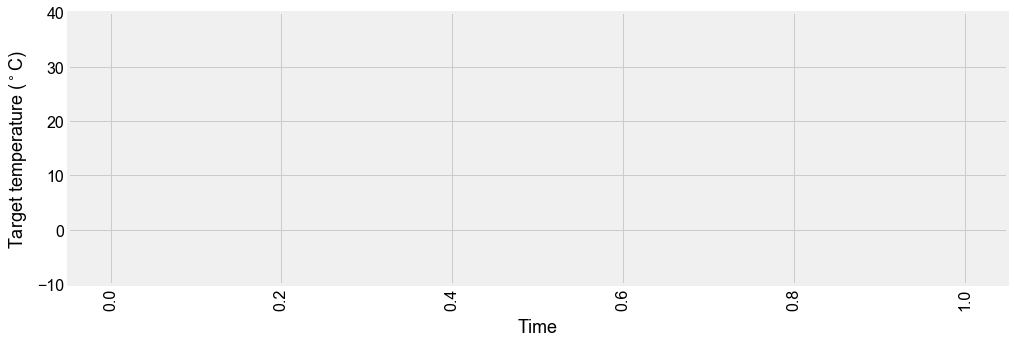

In [11]:
# create a new data frames
df_date_targetY = pd.DataFrame()
df_date_targetY["DateTime"] = df.iloc[:in_train_num:6, 0]
df_date_targetY["Tmean"] = pd.Series(ar_trainY)
df_date_targetY.head()

# plot temperature as a function of time
fig  = plt.figure(figsize=(15, 5))
ax    = fig.add_subplot(111)
plt.plot('DateTime', 'Tmean', data=df_date_targetY ,color='blue', linewidth=1.5)

ax.tick_params(axis="x", labelrotation=90, labelsize=16)
plt.yticks(np.arange(-10, 45, 10), fontsize=16)
ax.set_xlabel('Time', axis_font, labelpad=8)
ax.set_ylabel("Target temperature ($^\circ$C)", axis_font, labelpad=8)
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler

oj_std_scale = StandardScaler()
oj_std_scale.fit(ar_trainX)
ar_train_scaleX = oj_std_scale.transform(ar_trainX)
ar_test_scaleX  = oj_std_scale.transform(ar_testX)

In [13]:
ar_trainX[0:2,:]


array([[ 1.21411765e+00,  1.63803529e+02,  3.87058824e-01,
         2.15647059e+00, -2.50588235e-01,  7.52437647e+02,
         9.98717647e+01,  4.64705882e-02,  6.12764706e+00,
         4.89352941e+00,  1.27418824e+00,  3.32012941e+02],
       [ 5.64117647e-01,  1.98428235e+02,  2.18235294e-01,
         9.44705882e-01, -1.57058824e-01,  7.82092941e+02,
         1.00000000e+02, -3.54400000e+01,  3.01764706e-01,
         2.38823529e-01,  1.52592353e+00,  3.09403529e+02]])

In [14]:
ar_train_scaleX[0:2,:]


array([[-0.64769996, -0.10407781, -0.24031632, -0.72641625, -0.88096631,
        -0.1521987 ,  0.94028383,  0.04485799, -0.36047736, -0.36084152,
         0.328748  , -0.28394937],
       [-1.32850418,  0.39319046, -0.77165867, -1.33548444, -0.55078284,
         2.97841163,  0.94557898, -2.82119947, -1.30893518, -1.32910282,
         1.00446743, -2.81291104]])

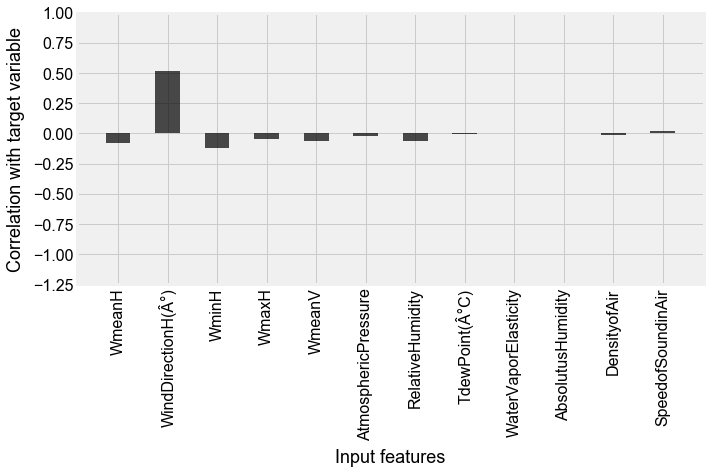

In [15]:
ve_X_labels = np.array([ts_columns_int[i] for i in ar_idxes_int])
ve_correls = np.zeros((ar_train_scaleX.shape[-1]))
for i in range(0, ar_train_scaleX.shape[-1]): 
    b = np.corrcoef(ar_train_scaleX[:, i], ar_trainY, rowvar=False)
    ve_correls[i] = b[0,1]

# Figure 
fig  = plt.figure(figsize=(10, 5))
ax    = fig.add_subplot(111)
in_width = 0.5
ar_idxes = np.arange(ve_correls.shape[0])
p1=ax.bar(ar_idxes, ve_correls, in_width, color='k', edgecolor='none', alpha=0.7)
plt.xticks(ar_idxes, ve_X_labels, fontsize=16, rotation=90)
plt.yticks(np.arange(-1.25, 1.25, 0.25), fontsize=16)
ax.set_xlabel('Input features', axis_font, labelpad=8)
ax.set_ylabel("Correlation with target variable", axis_font, labelpad=8)
plt.show()

In [16]:
for st_label, fo_corr in zip(ve_X_labels, ve_correls):
    print(f"{st_label:20} = {fo_corr:5.2f}")

WmeanH               = -0.08
WindDirectionH(Â°)   =  0.52
WminH                = -0.12
WmaxH                = -0.05
WmeanV               = -0.06
AtmosphericPressure  = -0.02
RelativeHumidity     = -0.06
TdewPoint(Â°C)       = -0.01
WaterVaporElasticity =  0.00
AbsolutusHumidity    =  0.00
DensityofAir         = -0.01
SpeedofSoundinAir    =  0.02


['WmeanH', 'WindDirectionH(Â°)', 'WminH', 'WmaxH', 'WmeanV', 'AtmosphericPressure', 'RelativeHumidity', 'TdewPoint(Â°C)', 'WaterVaporElasticity', 'AbsolutusHumidity', 'DensityofAir', 'SpeedofSoundinAir'] 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158156 entries, 0 to 158155
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   WmeanH                158156 non-null  float64
 1   WindDirectionH(Â°)    158156 non-null  float64
 2   WminH                 158156 non-null  float64
 3   WmaxH                 158156 non-null  float64
 4   WmeanV                158156 non-null  float64
 5   AtmosphericPressure   158156 non-null  float64
 6   RelativeHumidity      158156 non-null  float64
 7   TdewPoint(Â°C)        158156 non-null  float64
 8   WaterVaporElasticity  158156 non-null  float64
 9   AbsolutusHumidity     158156 non-null  float64
 10  DensityofAir          158156 non-null  float64
 11  S

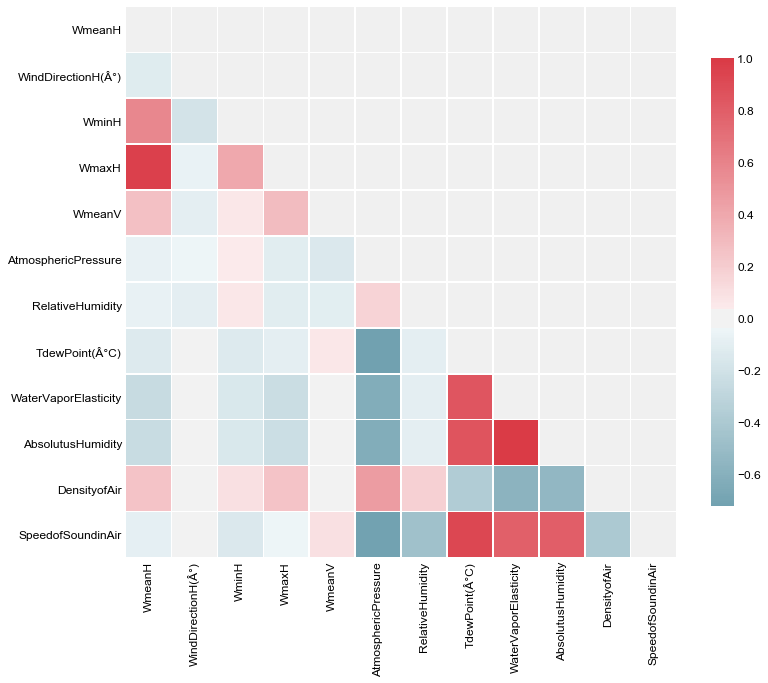

In [17]:
print(ts_columns_int, len(ts_columns_int))
# get new data frame to compute correlation
df_norm_data = pd.DataFrame(ar_train_scaleX, columns = ts_columns_int)
df_norm_data.info()

# correlation matrix - contains correlation among attributes
ar_corr_mat = df_norm_data.corr()

# Generate a mask for the upper triangle
ar_mask = np.zeros_like(ar_corr_mat, dtype=np.bool)
ar_mask[np.triu_indices_from(ar_mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 11))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(ar_corr_mat, mask=ar_mask, cmap=cmap, vmax=1.0, 
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .75})

In [ ]:
fo_threshold = 0.95
ar_upper_mat    = ar_corr_mat.where(np.triu(np.ones(ar_corr_mat.shape), k=1).astype(np.bool))
ts_hilo_corr_up = [column for column in ar_upper_mat.columns
                           if any(np.abs(ar_upper_mat[column]) >= fo_threshold)]

ar_lower_mat    = ar_corr_mat.where(np.tril(np.ones(ar_corr_mat.shape), k=-1).astype(np.bool))
ts_hilo_corr_lo = [column for column in ar_lower_mat.columns
                           if any(np.abs(ar_lower_mat[column]) >= fo_threshold)]

ts_hilo_corr_attributes = np.union1d(ts_hilo_corr_up, ts_hilo_corr_lo)

#ts_hilo_corr_attributes
print("Attributes that have strong (anti)correlation with one")
for idx, st_attribute in enumerate(ts_hilo_corr_attributes):
    print("{}. {}".format(idx+1, st_attribute))
print("===")

ts_no_corr_attributes= np.setdiff1d(ar_upper_mat.columns, ts_hilo_corr_attributes)
print("Attributes that have no correlation")
for idx, st_attribute in enumerate(ts_no_corr_attributes):
    print("{}. {}".format(idx+1, st_attribute))
print("===")